[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nailahafifah/uas-statistika/blob/main/Nailah_Afifah_F5212520034.ipynb)

# Prediksi Pendapatan Bulanan Berdasarkan Pendidikan, Pengalaman Kerja, dan Jam Kerja

**Nama** : Nailah Afifah  
**NIM** : F5212520034  
**Kelas** : Sistem Informasi A  
**Mata Kuliah** : Statistika dan Probabilitas

---

Pendapatan pekerja dipengaruhi oleh berbagai faktor seperti tingkat pendidikan, pengalaman kerja, dan jumlah jam kerja. Pada penelitian ini digunakan metode **regresi linear berganda** untuk melihat hubungan faktor-faktor tersebut terhadap pendapatan bulanan pekerja berdasarkan data Sakernas BPS.

**Pengertian Regresi**  
Regresi adalah metode statistik yang digunakan untuk melihat hubungan antar variabel dan memprediksi suatu nilai berdasarkan data yang sudah ada.

**Model Regresi**  
Model regresi linear berganda yang digunakan adalah:  
$$Y = a + b_1X_1 + b_2X_2 + b_3X_3$$

Keterangan:
- $Y$ = Pendapatan Bulanan
- $X_1$ = Tingkat Pendidikan
- $X_2$ = Pengalaman Kerja
- $X_3$ = Jam Kerja

**Penjelasan Variabel**
- **Pendapatan Bulanan (Y)**: jumlah penghasilan pekerja per bulan (juta rupiah).
- **Tingkat Pendidikan (X1)**: lama pendidikan formal pekerja (tahun).
- **Pengalaman Kerja (X2)**: lama pengalaman bekerja dalam tahun.
- **Jam Kerja (X3)**: jumlah jam kerja per minggu.

# Data Collecting

Dataset yang digunakan bersumber dari **Survei Angkatan Kerja Nasional (Sakernas) BPS** yang dapat diakses melalui situs resmi BPS:
[https://www.bps.go.id/id/statistics-table/2/NjMjMg==/jumlah-penduduk-yang-bekerja-menurut-lapangan-pekerjaan-utama.html](https://www.bps.go.id/id/statistics-table/2/NjMjMg==/jumlah-penduduk-yang-bekerja-menurut-lapangan-pekerjaan-utama.html)

Data terdiri dari **100 baris** dengan variabel:
- `Pendidikan` — lama pendidikan formal (tahun): 6, 9, 12, 14, 16
- `Pengalaman_Kerja` — pengalaman bekerja (tahun)
- `Jam_Kerja` — jam kerja per minggu
- `Pendapatan` — pendapatan bulanan (juta rupiah)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Membuat dataset Sakernas BPS (100 data)
data = {
    'Pendidikan': [
        6,6,6,6,6,6,6,6,6,6,6,
        9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,
        12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,
        14,14,14,14,14,14,14,14,14,14,14,14,14,14,14,14,14,14,
        16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,16,
        16,16,16,16,16,16,16,16,16,16,16,16,16,16,16
    ],
    'Pengalaman_Kerja': [
        2,3,4,5,6,7,8,9,10,11,12,
        2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,
        2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,
        2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
        2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,
        20,21,22,23,24,25,26,27,28,29,30,31,32,33,34
    ],
    'Jam_Kerja': [
        35,36,37,38,39,40,41,42,43,44,45,
        36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,
        38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,
        40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,
        42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,
        60,61,62,63,64,65,66,67,67,67,67,67,67,67,67
    ],
    'Pendapatan': [
        1.8,1.9,2.0,2.1,2.2,2.3,2.4,2.5,2.6,2.7,2.8,
        2.2,2.3,2.4,2.5,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5,3.6,3.7,
        2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5,3.6,3.7,3.8,3.9,4.0,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,
        3.5,3.6,3.7,3.8,3.9,4.0,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9,5.0,5.1,5.2,
        4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9,5.0,5.1,5.2,5.3,5.4,5.5,5.6,5.7,5.8,5.9,
        6.0,6.1,6.2,6.3,6.4,6.5,6.6,6.7,6.8,6.9,7.0,7.1,7.2,7.3,7.4
    ]
}

df = pd.DataFrame(data)
df.insert(0, 'No', range(1, len(df)+1))

# Exploratory Data Analysis

In [ ]:
# Menampilkan 5 data awal untuk memastikan data terbaca
print(df.head())

   No  Pendidikan  Pengalaman_Kerja  Jam_Kerja  Pendapatan
0   1           6                 2         35         1.8
1   2           6                 3         36         1.9
2   3           6                 4         37         2.0
3   4           6                 5         38         2.1
4   5           6                 6         39         2.2


In [ ]:
df.describe()

,No,Pendidikan,Pengalaman_Kerja,Jam_Kerja,Pendapatan
count,99.000000,99.000000,99.000000,99.000000,99.000000
mean,50.000000,12.545455,12.767677,49.525253,4.262626
std,28.722813,3.366318,7.980625,8.803227,1.426898
min,1.000000,6.000000,2.000000,35.000000,1.800000
25%,25.500000,9.000000,6.500000,43.000000,3.150000
50%,50.000000,14.000000,11.000000,48.000000,4.200000
75%,74.500000,16.000000,17.000000,55.000000,5.100000
max,99.000000,16.000000,34.000000,67.000000,7.400000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   No                99 non-null     int64  
 1   Pendidikan        99 non-null     int64  
 2   Pengalaman_Kerja  99 non-null     int64  
 3   Jam_Kerja         99 non-null     int64  
 4   Pendapatan        99 non-null     float64
dtypes: float64(1), int64(4)
memory usage: 4.0 KB


In [ ]:
df.shape

(99, 5)

In [ ]:
df.isnull().sum()

,0
No,0
Pendidikan,0
Pengalaman_Kerja,0
Jam_Kerja,0
Pendapatan,0


In [ ]:
df.duplicated().sum()

np.int64(0)


==== Deteksi Outlier dengan IQR pada kolom Pendapatan ====
Batas Bawah : 0.22500000000000142
Batas Atas  : 8.024999999999999
Jumlah Pendapatan Outlier : 0 baris dari total 99 baris data


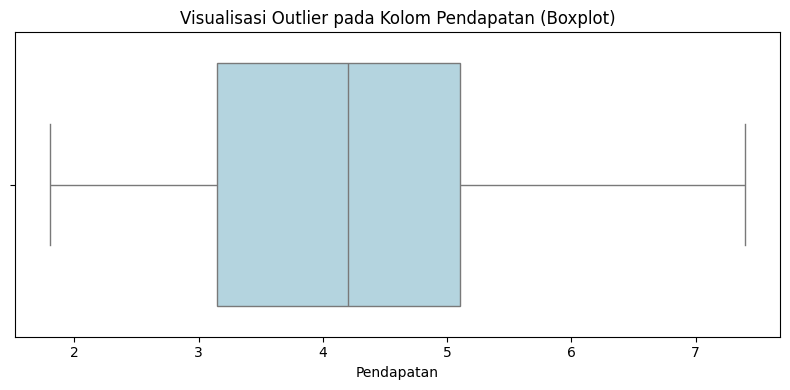

In [ ]:
# DETEKSI DAN VISUALISASI OUTLIER (PENCILAN)

kolom_target = 'Pendapatan'

print(f"\n==== Deteksi Outlier dengan IQR pada kolom {kolom_target} ====")

Q1 = df[kolom_target].quantile(0.25)
Q3 = df[kolom_target].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mencari data yang berada di luar batas (outlier)
outliers = df[(df[kolom_target] < lower_bound) | (df[kolom_target] > upper_bound)]
print(f"Batas Bawah : {lower_bound}")
print(f"Batas Atas  : {upper_bound}")
print(f"Jumlah {kolom_target} Outlier : {len(outliers)} baris dari total {len(df)} baris data")

# Visualisasi Outlier dengan Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df[kolom_target], color='lightblue')
plt.title(f'Visualisasi Outlier pada Kolom {kolom_target} (Boxplot)')
plt.xlabel(kolom_target)
plt.tight_layout()
plt.show()

# Data Preprocessing

In [ ]:
print(f"Jumlah data sebelum dihapus: {len(df)}")

# Menghapus baris yang nilai pendapatannya di bawah batas bawah atau di atas batas atas
df = df[(df['Pendapatan'] >= lower_bound) & (df['Pendapatan'] <= upper_bound)]

print(f"Jumlah data setelah dihapus: {len(df)}")

Jumlah data sebelum dihapus: 99
Jumlah data setelah dihapus: 99


In [ ]:
# Memilih kolom yang penting untuk analisis
# Kita gunakan:
# - Pendidikan        sebagai X1
# - Pengalaman_Kerja  sebagai X2
# - Jam_Kerja         sebagai X3
# - Pendapatan        sebagai target (Y)
df = df[['Pendidikan', 'Pengalaman_Kerja', 'Jam_Kerja', 'Pendapatan']]

# Menampilkan informasi dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pendidikan        99 non-null     int64  
 1   Pengalaman_Kerja  99 non-null     int64  
 2   Jam_Kerja         99 non-null     int64  
 3   Pendapatan        99 non-null     float64
dtypes: float64(1), int64(3)
memory usage: 3.2 KB
None


In [ ]:
# Menentukan fitur (X) dan target (y)
# X = data input
# y = pendapatan yang akan diprediksi
X = df[['Pendidikan', 'Pengalaman_Kerja', 'Jam_Kerja']]
y = df['Pendapatan']

# Membagi data menjadi data latih dan data uji
# 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Training

In [ ]:
# Membuat model Regresi Linear Berganda
model = LinearRegression()

# Melatih model menggunakan data latih
model.fit(X_train, y_train)

# Melakukan prediksi pada data uji
y_pred = model.predict(X_test)

# Menampilkan koefisien model
print("=== KOEFISIEN MODEL REGRESI ===")
print(f"Intercept (a)                   : {model.intercept_:.4f}")
print(f"Koefisien Pendidikan (b1)       : {model.coef_[0]:.4f}")
print(f"Koefisien Pengalaman Kerja (b2) : {model.coef_[1]:.4f}")
print(f"Koefisien Jam Kerja (b3)        : {model.coef_[2]:.4f}")
print(f"\nPersamaan Model:")
print(f"Y = {model.intercept_:.4f} + {model.coef_[0]:.4f}*X1 + {model.coef_[1]:.4f}*X2 + {model.coef_[2]:.4f}*X3")

=== KOEFISIEN MODEL REGRESI ===
Intercept (a)                   : -2.2883
Koefisien Pendidikan (b1)       : 0.1989
Koefisien Pengalaman Kerja (b2) : 0.0359
Koefisien Jam Kerja (b3)        : 0.0727

Persamaan Model:
Y = -2.2883 + 0.1989*X1 + 0.0359*X2 + 0.0727*X3


## Visualisasi

/tmp/ipykernel_5199/86101834.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, color='red')


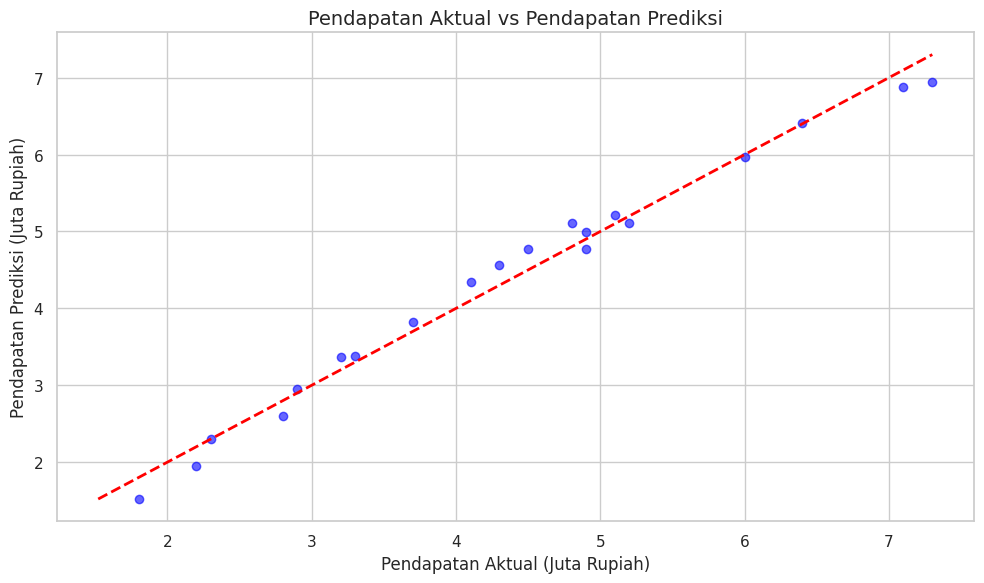

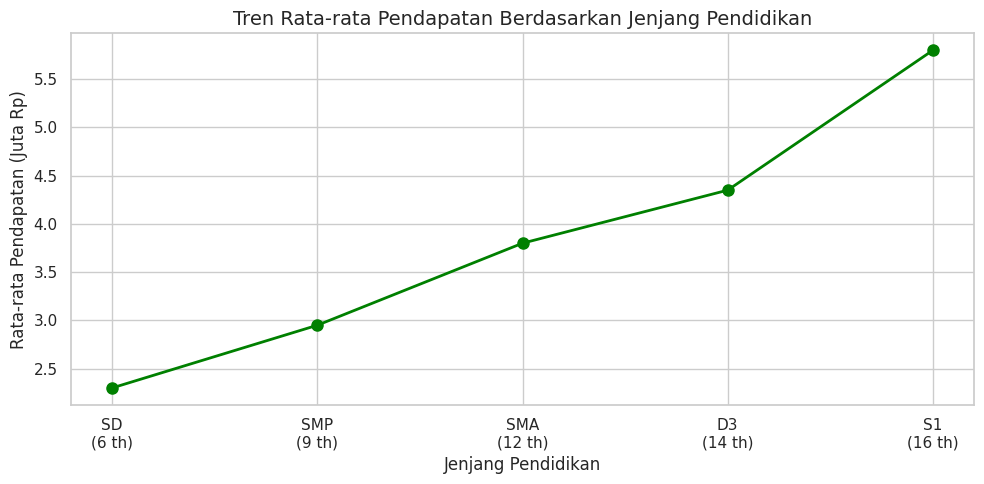

In [ ]:
# Mengatur gaya plot
sns.set_theme(style="whitegrid")

# VISUALISASI 1: Pendapatan Aktual vs Pendapatan Prediksi (Scatter Plot)
# Untuk melihat seberapa akurat prediksi model terhadap data asli.
# Semakin titik-titik mendekati garis putus-putus merah, semakin baik modelnya.
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')

# Membuat garis referensi diagonal (jika prediksi 100% akurat)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, color='red')

plt.title('Pendapatan Aktual vs Pendapatan Prediksi', fontsize=14)
plt.xlabel('Pendapatan Aktual (Juta Rupiah)', fontsize=12)
plt.ylabel('Pendapatan Prediksi (Juta Rupiah)', fontsize=12)
plt.tight_layout()
plt.show()

# VISUALISASI 2: Tren Rata-rata Pendapatan Berdasarkan Jenjang Pendidikan
# Melihat hubungan antara tingkat pendidikan dan rata-rata pendapatan
plt.figure(figsize=(10, 5))

trend_data = df.groupby('Pendidikan')['Pendapatan'].mean().reset_index()
label_pend = {6: 'SD\n(6 th)', 9: 'SMP\n(9 th)', 12: 'SMA\n(12 th)', 14: 'D3\n(14 th)', 16: 'S1\n(16 th)'}
trend_data['Label'] = trend_data['Pendidikan'].map(label_pend)

plt.plot(trend_data['Label'], trend_data['Pendapatan'], marker='o', color='green', linewidth=2, markersize=8)
plt.title('Tren Rata-rata Pendapatan Berdasarkan Jenjang Pendidikan', fontsize=14)
plt.xlabel('Jenjang Pendidikan', fontsize=12)
plt.ylabel('Rata-rata Pendapatan (Juta Rp)', fontsize=12)
plt.tight_layout()
plt.show()

# Evaluasi Model

| Metrik | Digunakan ketika                                          |
| ------ | --------------------------------------------------------- |
| MAE    | Jika Ingin mengetahui rata-rata kesalahan secara langsung |
| MSE    | Jika Error besar harus dihukum lebih berat                |
| RMSE   | Jika Ingin ukuran error yang mudah diinterpretasikan      |
| R²     | Jika Ingin melihat seberapa baik model menjelaskan data   |

In [ ]:
# Menghitung evaluasi model
# MAE  = Mean Absolute Error
# RMSE = Root Mean Squared Error

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== EVALUASI MODEL ===")
print("R2   :", round(r2, 4))
print("MSE  :", round(mse, 4))
print("MAE  :", round(mae, 4))
print("RMSE :", round(rmse, 4))

# Menampilkan contoh hasil prediksi
hasil_uji = pd.DataFrame({
    "Pendapatan Asli": y_test.values[:10],
    "Pendapatan Prediksi": y_pred[:10].round(2)
})

print("\n=== CONTOH HASIL PREDIKSI ===")
print(hasil_uji)


=== EVALUASI MODEL ===
R2   : 0.9845
MSE  : 0.0372
MAE  : 0.163
RMSE : 0.1928

=== CONTOH HASIL PREDIKSI ===
   Pendapatan Asli  Pendapatan Prediksi
0              4.9                 5.00
1              4.1                 4.34
2              7.1                 6.88
3              2.9                 2.95
4              7.3                 6.95
5              6.0                 5.97
6              5.1                 5.21
7              4.3                 4.56
8              2.8                 2.61
9              1.8                 1.52


# Deployment

In [ ]:
# Membuat mapping kode jenjang pendidikan
# Agar user tahu angka mana untuk jenjang pendidikan tertentu
mapping_pendidikan = {
    6 : 'SD',
    9 : 'SMP',
    12: 'SMA/SMK',
    14: 'D3 / Diploma',
    16: 'S1 / Sarjana'
}

print("=== DAFTAR KODE JENJANG PENDIDIKAN ===")
for kode, nama in mapping_pendidikan.items():
    print(f"{kode:>3} : {nama}")

# Input data baru dari pengguna
# User memasukkan pendidikan, pengalaman, dan jam kerja
print("\n=== PREDIKSI PENDAPATAN BARU ===")
pendidikan       = int(input("Masukkan kode jenjang pendidikan (6/9/12/14/16): "))
pengalaman_kerja = int(input("Masukkan pengalaman kerja (tahun)             : "))
jam_kerja        = int(input("Masukkan jam kerja per minggu                 : "))

# Menyiapkan data baru ke dalam DataFrame
data_baru = pd.DataFrame([{
    'Pendidikan'      : pendidikan,
    'Pengalaman_Kerja': pengalaman_kerja,
    'Jam_Kerja'       : jam_kerja
}])

# Melakukan prediksi pendapatan untuk data baru
prediksi_baru = model.predict(data_baru)[0]

# Menampilkan hasil prediksi akhir
print("\n=== HASIL PREDIKSI BARU ===")
print("Jenjang Pendidikan   :", mapping_pendidikan.get(pendidikan, f"{pendidikan} tahun"))
print("Pengalaman Kerja     :", pengalaman_kerja, "tahun")
print("Jam Kerja per Minggu :", jam_kerja, "jam")
print("Prediksi Pendapatan  : Rp", round(prediksi_baru, 2), "Juta / Bulan")

=== DAFTAR KODE JENJANG PENDIDIKAN ===
  6 : SD
  9 : SMP
 12 : SMA/SMK
 14 : D3 / Diploma
 16 : S1 / Sarjana

=== PREDIKSI PENDAPATAN BARU ===
